In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date, timedelta
import os
import warnings
from tqdm.notebook import tqdm
from House2O import general_use

print(os.getcwd())

notebook_dir = os.getcwd()
sys.path.insert(0, os.path.join(os.getcwd(), "House2O"))
test = notebook_dir.copy()

print(sys.path[0])

if 'House2O' in sys.modules:
    del sys.modules['House2O']

c:\Users\Matti\Documents\GitHub\House2O\House2O
c:\Users\Matti\Documents\GitHub\House2O\House2O\House2O


# MET DE CODE IN DE VOLGENDE CELL KAN JE SPELEN
# LAAT DE CODE IN DE CEL ERONDER ONAANGEROERD AJB

In [ ]:


# ALS JE IETS TEST, pas dan het LABEL AAAAAAAN
# ANDERS WORDEN DE RESULTATEN OVERSCHREVEN

# ============================================================
# CONFIGURATION
# ============================================================
LAT           = 51.222  # latitude coordinate
LON           = 4.401   # longitude coordinate
# set start and end date. If both are equal, the algorithm is ran for only one day, showing different plots
START_DATE    = date(2024, 3, 1)   
END_DATE      = date(2024, 3, 31)      
# set the hours over which to loop, second value (final hour) is exclusive
HOURS         = list(range(6, 22, 1))
DAY_STEP      = 1
ANGLE_MIN     = 0
ANGLE_MAX     = 90
ANGLE_STEP    = 10
LABEL         = "test" # Label can be handy to include if you want to name a specific run in a convenient way   
SAVE_DIR      = r"C:\Users\Matti\Documents\GitHub\House2O\output_plots\OptimalAngle" # place where the output (csv and plots) will be saved

# ============================================================
# creates csv if it doesn't exist yet
CACHE_FILE    = os.path.join(SAVE_DIR, f"{LABEL.replace(' ', '_').replace('/', '-')}_cache.csv") 
os.makedirs(SAVE_DIR, exist_ok=True)

SINGLE_DAY = (START_DATE == END_DATE) # checks to see if only one day or multiple have to be evaluated


# ── Build day / angle lists ───────────────────────────────────
all_days, d = [], START_DATE # all_days has to be a list, d is set as START_DATE
# adds to the list adding all requested days in the right format
while d <= END_DATE:
    all_days.append(d)
    d += timedelta(days=DAY_STEP)

all_angles   = list(range(ANGLE_MIN, ANGLE_MAX + 1, ANGLE_STEP)) # creates a lit of angles, 2nd parameter of range is exclusive, thus + 1
total_calls  = len(all_angles) * len(all_days) * len(HOURS) # calculates total number of counts to show the user

# ── Display configuration ─────────────────────────────────────
HOUR_STEP_SIZE = HOURS[1] - HOURS[0] # finds hours stepsize
date_range_str = str(START_DATE) if SINGLE_DAY else f"{START_DATE} → {END_DATE} (every {DAY_STEP} days)" # create variable to pring date range

print(f"Mode:       {'SINGLE DAY' if SINGLE_DAY else 'MULTI-DAY'}") # print SINGLE DATE or date range if multiple day mode 
print(f"Days:       {date_range_str}") # prints what days you evaluate 
print(f"Hours:      {HOURS[0]:02d}:00 → {HOURS[-1]:02d}:00, step: {HOUR_STEP_SIZE}h") # prints evaluated range of hours
print(f"Angles:     {ANGLE_MIN}° → {ANGLE_MAX}°, step: {ANGLE_STEP}°") # prints evaluated range of angles
print(f"Label:      {LABEL}")   # prints label

# ── Load or init cache ────────────────────────────────────────
if os.path.exists(CACHE_FILE): # if a file with the chosen configuration already exists
    cache_df = pd.read_csv(CACHE_FILE) # this file is being read 
    cache_df = cache_df.drop_duplicates(subset=["angle", "date", "hour"], keep="last") # removes duplicates in the csv that could have been accidentally created (after a crash/interruption for example)
    cache    = set(zip(cache_df["angle"], cache_df["date"], cache_df["hour"])) # retrieves unique new computation request such that what's already in the csv doesn't get computed again
    records  = cache_df.to_dict("records") # these are the already completed computations
    print(f"Resuming from cache — {len(records)} results already stored.") # prints to say that the current configuration has already (partly) been executed before and continues from there 
else:
    cache, records = set(), [] # if no such file is found, it 
    print("Starting fresh.") # it starts fresh

# ── Main sweep ────────────────────────────────────────────────
call_count = 0 # keeps count of the number of counts
total_remaining = max(0, total_calls-len(cache)) # computes the number of calls that still have to be executed
print(f"Total computations: {total_remaining:,}\n") # prints this number

# ignore warnings for angles and hours that result in 0W
with warnings.catch_warnings(): 
    warnings.simplefilter("ignore", RuntimeWarning)

    # use tqdm to display a progress bar
    bar = tqdm(
        total=total_remaining,
        desc="Processing",
        unit="call",
        dynamic_ncols=True,
    )
    # loop over all angles
    for angle in all_angles:
        # loop over all days
        for day in all_days:
            day_str = day.strftime("%Y-%m-%d") # create correct day string
            # loop over all hours
            for hour in HOURS:
                key = (angle, day_str, hour) # create key with specific data
                if key in cache: # check if key is in cache
                    continue # if so, nothing has to be computed anymore

                # if not:
                datetime_str = f"{day_str} {hour:02d}:00" # new string that includes both day and hour
                try:
                    # use Xander's function to calculate the absorbed solar energy for specific location, time and angle
                    _, _, power = general_use(
                        LAT=LAT, LON=LON,
                        DATETIME=datetime_str,
                        surface_tilt=angle,
                        print_details=False,
                    )
                except Exception as e:
                    # handling cases of angles and hours that are empty/zero/problematic
                    tqdm.write(f"  [ERROR] {datetime_str} angle={angle}°: {e}") 
                    power = 0.0 # returns power = 0W

                records.append({"angle": angle, "date": day_str, "hour": hour, "power": power}) # add the specific computation and its result to the records
                cache.add(key) # add to cache as well
                call_count += 1 # up the number of counts
                bar.update(1) # update the displayed bar from tqdm

        pd.DataFrame(records).to_csv(CACHE_FILE, index=False) # save records to the csv file

    bar.close() # close the progress bar

# ── Aggregate ─────────────────────────────────────────────────
df               = pd.DataFrame(records) # create a dataframe from the records to display later
df = df.drop_duplicates(subset=["angle", "date", "hour"], keep="last") # drop duplicates


# creates function to integrate over all hours to get the total absorbed power over the full range of time
def trapezoid_energy(group):
    g = group.sort_values("hour").dropna(subset = ["power"]) # sort the values and drop nan's to avoid problems
    return np.trapezoid(g["power"], dx = HOUR_STEP_SIZE) # return integrated power value

# calculate the total energy per angle
energy_per_angle = (df.groupby(["angle", "date"]) # group angle and date
                    .apply(trapezoid_energy, include_groups = False) # calculate total amount of absorbed power
                    .groupby("angle") # group by angle
                    .sum() # sum all energy values for that angle
                    .reset_index()) # promotes the index back to column to avoid problems with pd dataframe

energy_per_angle.columns = ["angle", "total_energy_Wh-m2"] # 

best_row   = energy_per_angle.loc[energy_per_angle["total_energy_Wh-m2"].idxmax()] # finds position of most amount of absorbed power in the csv
best_angle = int(best_row["angle"]) # finds corresponding optimal angle
best_power = best_row["total_energy_Wh-m2"] # finds maximum value of absorbed energy

# print analysis result
print(f"\n{'='*55}")
print(f"  LABEL:                  {LABEL}") 
print(f"  OPTIMAL ANGLE (coarse): {best_angle}°")
print(f"  Total absorbed energy:  {best_power:.1f} W")
print(f"{'='*55}")

# ── Safe filename fragment from label ─────────────────────────
label_slug = LABEL.replace(" ", "_").replace("/", "-")

# ══════════════════════════════════════════════════════════════
#  SINGLE-DAY PLOTS
# ══════════════════════════════════════════════════════════════
if SINGLE_DAY:
    day_str  = START_DATE.strftime("%Y-%m-%d") # get start_date in the right format
    day_df   = df[df["date"] == day_str].copy() # copy that day

    # --- Plot A: hourly power at the optimal angle -------------
    opt_df   = day_df[day_df["angle"] == best_angle].sort_values("hour") # find all values of the optimal angle
    # create figure and axes
    fig, ax  = plt.subplots(figsize=(9, 4))
    # configure axes
    ax.bar(opt_df["hour"], opt_df["power"], width=1.6,
           color="steelblue", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Hour of day", fontsize=12)
    ax.set_ylabel("Absorbed power (W)", fontsize=12)
    ax.set_xticks(opt_df["hour"])
    ax.set_xticklabels([f"{h:02d}:00" for h in opt_df["hour"]], rotation=30)
    ax.set_title(
        f"{LABEL}\nHourly absorption at optimal tilt ({best_angle}°) — {day_str}",
        fontsize=12,
    )
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_{day_str}_hourly_optimal.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig 

    # --- Plot B: total daily energy per angle ------------------
    # create figure and axes
    fig, ax = plt.subplots(figsize=(9, 4))
    # configure axes
    ax.plot(energy_per_angle["angle"], energy_per_angle["total_energy_Wh-m2"],
            "o-", color="darkorange", lw=2, markersize=7)
    ax.axvline(best_angle, color="red", linestyle="--", lw=1.5,
               label=f"Optimal: {best_angle}°")
    ax.scatter([best_angle], [best_power], color="red", zorder=5, s=100)
    ax.set_xlabel("Surface tilt angle (°)", fontsize=12)
    ax.set_ylabel("Total daily energy (W·samples)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nTotal energy vs tilt angle — {day_str}",
        fontsize=12,
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_{day_str}_energy_vs_angle.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig

# ══════════════════════════════════════════════════════════════
#  MULTI-DAY PLOTS  (unchanged logic, label added)
# ══════════════════════════════════════════════════════════════
else:
    # --- Plot 1: total energy vs angle ------------------------
    # create figure and axes
    fig, ax = plt.subplots(figsize=(10, 5)) 
    # configure axes
    ax.plot(energy_per_angle["angle"], energy_per_angle["total_energy_Wh-m2"],
            "o-", color="steelblue", lw=2, markersize=7)
    ax.axvline(best_angle, color="red", linestyle="--", lw=1.5,
               label=f"Optimal: {best_angle}°")
    ax.scatter([best_angle], [best_power], color="red", zorder=5, s=100)
    ax.set_xlabel("Surface Tilt Angle (°)", fontsize=12)
    ax.set_ylabel("Total Absorbed Energy (W·samples)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nSeasonal Energy vs Tilt Angle ({ANGLE_STEP}° steps)\n"
        f"{START_DATE} → {END_DATE} | every {DAY_STEP} days | hours: {HOURS[0]}h–{HOURS[-1]}h",
        fontsize=12,
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_energy_vs_angle.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig 

    # --- Plot 2: heatmap angle × day --------------------------
    pivot  = df.groupby(["angle", "date"])["power"].sum().unstack("date") # change data into heatmap compatible 2D grid
    # create fig and axes
    fig, ax = plt.subplots(figsize=(16, 6))
    # create heatmap image
    im = ax.imshow(pivot.values, aspect="auto", cmap="inferno", origin="lower",
                   extent=[0, len(pivot.columns), pivot.index.min(), pivot.index.max()])
    # add colorbar
    plt.colorbar(im, ax=ax, label="Daily Energy (W·samples)")
    # configure axes and provide information
    ax.set_yticks(pivot.index)
    ax.set_yticklabels([f"{a}°" for a in pivot.index])
    n_dates  = len(pivot.columns)
    tick_pos = np.linspace(0, n_dates - 1, min(10, n_dates), dtype=int)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([list(pivot.columns)[i] for i in tick_pos],
                       rotation=45, ha="right")
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Tilt Angle (°)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nHeatmap: Daily Energy per Angle — {START_DATE} → {END_DATE}",
        fontsize=12,
    )
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_heatmap.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig

Mode:       MULTI-DAY — 2024-01-01 → 2024-12-31 (every 1 days)
Label:      full_year_coarse
Days:       366  (2024-01-01 → 2024-12-31, step: 1 day(s))
Hours:      06:00 → 21:00, step: 1h
Angles:     0° → 90°, step: 10°
Starting fresh.
Total computations: 58,560



Processing:   0%|          | 0/58560 [00:00<?, ?call/s]

  [ERROR] 2024-02-29 06:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 07:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 08:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 09:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 10:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 11:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 12:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 13:00 angle=0°: cannot access local variable 'PVGIS_index' where it is not associated with a value
  [ERROR] 2024-02-29 14:00 angle=0°: can

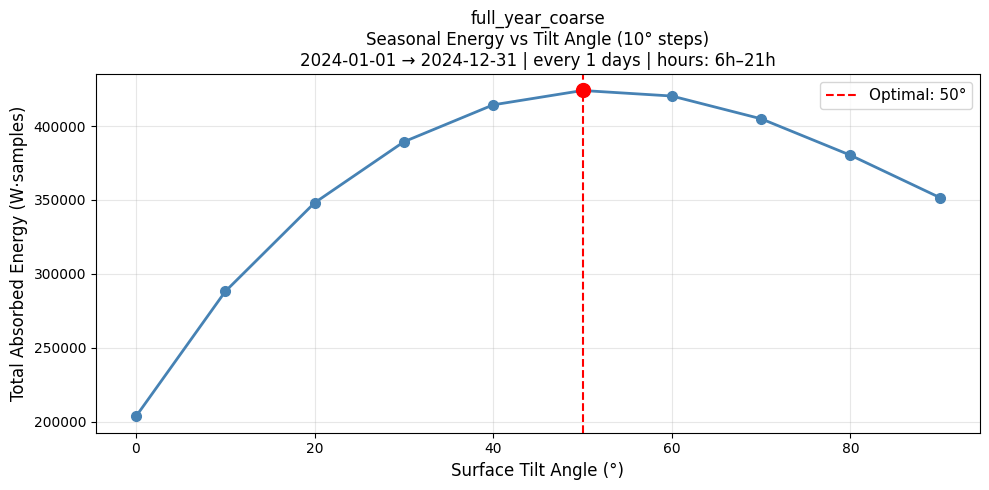

Saved: C:\Users\Matti\Documents\GitHub\House2O\output_plots\OptimalAngle\full_year_coarse_energy_vs_angle.png


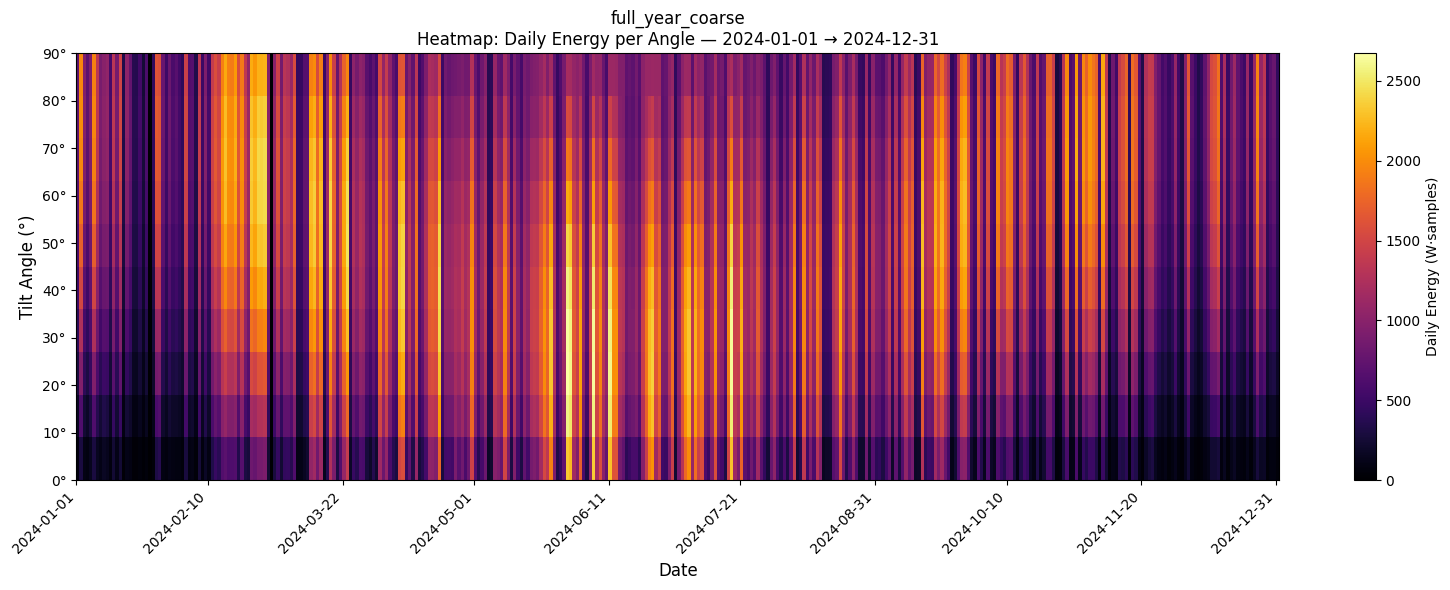

Saved: C:\Users\Matti\Documents\GitHub\House2O\output_plots\OptimalAngle\full_year_coarse_heatmap.png


In [3]:


# ALS JE IETS TEST, pas dan het LABEL AAAAAAAN
# ANDERS WORDEN DE RESULTATEN OVERSCHREVEN

# ============================================================
# CONFIGURATION
# ============================================================
LAT           = 51.222  # latitude coordinate
LON           = 4.401   # longitude coordinate
# set start and end date. If both are equal, the algorithm is ran for only one day, showing different plots
START_DATE    = date(2024, 1, 1)   
END_DATE      = date(2024, 12, 31)      
# set the hours over which to loop, second value (final hour) is exclusive
HOURS         = list(range(6, 22, 1))
DAY_STEP      = 1
ANGLE_MIN     = 0
ANGLE_MAX     = 90
ANGLE_STEP    = 10
LABEL         = "full_year_coarse" # Label can be handy to include if you want to name a specific run in a convenient way   
SAVE_DIR      = r"C:\Users\Matti\Documents\GitHub\House2O\output_plots\OptimalAngle" # place where the output (csv and plots) will be saved

# ============================================================
# creates csv if it doesn't exist yet
CACHE_FILE    = os.path.join(SAVE_DIR, f"{LABEL.replace(' ', '_').replace('/', '-')}_cache.csv") 
os.makedirs(SAVE_DIR, exist_ok=True)

SINGLE_DAY = (START_DATE == END_DATE) # checks to see if only one day or multiple have to be evaluated


# ── Build day / angle lists ───────────────────────────────────
all_days, d = [], START_DATE # all_days has to be a list, d is set as START_DATE
# adds to the list adding all requested days in the right format
while d <= END_DATE:
    all_days.append(d)
    d += timedelta(days=DAY_STEP)

all_angles   = list(range(ANGLE_MIN, ANGLE_MAX + 1, ANGLE_STEP)) # creates a lit of angles, 2nd parameter of range is exclusive, thus + 1
total_calls  = len(all_angles) * len(all_days) * len(HOURS) # calculates total number of counts to show the user

# ── Display configuration ─────────────────────────────────────
HOUR_STEP_SIZE = HOURS[1] - HOURS[0] # finds hours stepsize
date_range_str = str(START_DATE) if SINGLE_DAY else f"{START_DATE} → {END_DATE} (every {DAY_STEP} days)" # create variable to pring date range

print(f"Mode:       {'SINGLE DAY' if SINGLE_DAY else 'MULTI-DAY'}") # print SINGLE DATE or date range if multiple day mode 
print(f"Days:       {date_range_str}") # prints what days you evaluate 
print(f"Hours:      {HOURS[0]:02d}:00 → {HOURS[-1]:02d}:00, step: {HOUR_STEP_SIZE}h") # prints evaluated range of hours
print(f"Angles:     {ANGLE_MIN}° → {ANGLE_MAX}°, step: {ANGLE_STEP}°") # prints evaluated range of angles
print(f"Label:      {LABEL}")   # prints label

# ── Load or init cache ────────────────────────────────────────
if os.path.exists(CACHE_FILE): # if a file with the chosen configuration already exists
    cache_df = pd.read_csv(CACHE_FILE) # this file is being read 
    cache_df = cache_df.drop_duplicates(subset=["angle", "date", "hour"], keep="last") # removes duplicates in the csv that could have been accidentally created (after a crash/interruption for example)
    cache    = set(zip(cache_df["angle"], cache_df["date"], cache_df["hour"])) # retrieves unique new computation request such that what's already in the csv doesn't get computed again
    records  = cache_df.to_dict("records") # these are the already completed computations
    print(f"Resuming from cache — {len(records)} results already stored.") # prints to say that the current configuration has already (partly) been executed before and continues from there 
else:
    cache, records = set(), [] # if no such file is found, it 
    print("Starting fresh.") # it starts fresh

# ── Main sweep ────────────────────────────────────────────────
call_count = 0 # keeps count of the number of counts
total_remaining = max(0, total_calls-len(cache)) # computes the number of calls that still have to be executed
print(f"Total computations: {total_remaining:,}\n") # prints this number

# ignore warnings for angles and hours that result in 0W
with warnings.catch_warnings(): 
    warnings.simplefilter("ignore", RuntimeWarning)

    # use tqdm to display a progress bar
    bar = tqdm(
        total=total_remaining,
        desc="Processing",
        unit="call",
        dynamic_ncols=True,
    )
    # loop over all angles
    for angle in all_angles:
        # loop over all days
        for day in all_days:
            day_str = day.strftime("%Y-%m-%d") # create correct day string
            # loop over all hours
            for hour in HOURS:
                key = (angle, day_str, hour) # create key with specific data
                if key in cache: # check if key is in cache
                    continue # if so, nothing has to be computed anymore

                # if not:
                datetime_str = f"{day_str} {hour:02d}:00" # new string that includes both day and hour
                try:
                    # use Xander's function to calculate the absorbed solar energy for specific location, time and angle
                    _, _, power = general_use(
                        LAT=LAT, LON=LON,
                        DATETIME=datetime_str,
                        surface_tilt=angle,
                        print_details=False,
                    )
                except Exception as e:
                    # handling cases of angles and hours that are empty/zero/problematic
                    tqdm.write(f"  [ERROR] {datetime_str} angle={angle}°: {e}") 
                    power = 0.0 # returns power = 0W

                records.append({"angle": angle, "date": day_str, "hour": hour, "power": power}) # add the specific computation and its result to the records
                cache.add(key) # add to cache as well
                call_count += 1 # up the number of counts
                bar.update(1) # update the displayed bar from tqdm

        pd.DataFrame(records).to_csv(CACHE_FILE, index=False) # save records to the csv file

    bar.close() # close the progress bar

# ── Aggregate ─────────────────────────────────────────────────
df               = pd.DataFrame(records) # create a dataframe from the records to display later
df = df.drop_duplicates(subset=["angle", "date", "hour"], keep="last") # drop duplicates


# creates function to integrate over all hours to get the total absorbed power over the full range of time
def trapezoid_energy(group):
    g = group.sort_values("hour").dropna(subset = ["power"]) # sort the values and drop nan's to avoid problems
    return np.trapezoid(g["power"], dx = HOUR_STEP_SIZE) # return integrated power value

# calculate the total energy per angle
energy_per_angle = (df.groupby(["angle", "date"]) # group angle and date
                    .apply(trapezoid_energy, include_groups = False) # calculate total amount of absorbed power
                    .groupby("angle") # group by angle
                    .sum() # sum all energy values for that angle
                    .reset_index()) # promotes the index back to column to avoid problems with pd dataframe

energy_per_angle.columns = ["angle", "total_energy_Wh-m2"] # 

best_row   = energy_per_angle.loc[energy_per_angle["total_energy_Wh-m2"].idxmax()] # finds position of most amount of absorbed power in the csv
best_angle = int(best_row["angle"]) # finds corresponding optimal angle
best_power = best_row["total_energy_Wh-m2"] # finds maximum value of absorbed energy

# print analysis result
print(f"\n{'='*55}")
print(f"  LABEL:                  {LABEL}") 
print(f"  OPTIMAL ANGLE (coarse): {best_angle}°")
print(f"  Total absorbed energy:  {best_power:.1f} W")
print(f"{'='*55}")

# ── Safe filename fragment from label ─────────────────────────
label_slug = LABEL.replace(" ", "_").replace("/", "-")

# ══════════════════════════════════════════════════════════════
#  SINGLE-DAY PLOTS
# ══════════════════════════════════════════════════════════════
if SINGLE_DAY:
    day_str  = START_DATE.strftime("%Y-%m-%d") # get start_date in the right format
    day_df   = df[df["date"] == day_str].copy() # copy that day

    # --- Plot A: hourly power at the optimal angle -------------
    opt_df   = day_df[day_df["angle"] == best_angle].sort_values("hour") # find all values of the optimal angle
    # create figure and axes
    fig, ax  = plt.subplots(figsize=(9, 4))
    # configure axes
    ax.bar(opt_df["hour"], opt_df["power"], width=1.6,
           color="steelblue", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Hour of day", fontsize=12)
    ax.set_ylabel("Absorbed power (W)", fontsize=12)
    ax.set_xticks(opt_df["hour"])
    ax.set_xticklabels([f"{h:02d}:00" for h in opt_df["hour"]], rotation=30)
    ax.set_title(
        f"{LABEL}\nHourly absorption at optimal tilt ({best_angle}°) — {day_str}",
        fontsize=12,
    )
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_{day_str}_hourly_optimal.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig 

    # --- Plot B: total daily energy per angle ------------------
    # create figure and axes
    fig, ax = plt.subplots(figsize=(9, 4))
    # configure axes
    ax.plot(energy_per_angle["angle"], energy_per_angle["total_energy_Wh-m2"],
            "o-", color="darkorange", lw=2, markersize=7)
    ax.axvline(best_angle, color="red", linestyle="--", lw=1.5,
               label=f"Optimal: {best_angle}°")
    ax.scatter([best_angle], [best_power], color="red", zorder=5, s=100)
    ax.set_xlabel("Surface tilt angle (°)", fontsize=12)
    ax.set_ylabel("Total daily energy (W·samples)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nTotal energy vs tilt angle — {day_str}",
        fontsize=12,
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_{day_str}_energy_vs_angle.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig

# ══════════════════════════════════════════════════════════════
#  MULTI-DAY PLOTS  (unchanged logic, label added)
# ══════════════════════════════════════════════════════════════
else:
    # --- Plot 1: total energy vs angle ------------------------
    # create figure and axes
    fig, ax = plt.subplots(figsize=(10, 5)) 
    # configure axes
    ax.plot(energy_per_angle["angle"], energy_per_angle["total_energy_Wh-m2"],
            "o-", color="steelblue", lw=2, markersize=7)
    ax.axvline(best_angle, color="red", linestyle="--", lw=1.5,
               label=f"Optimal: {best_angle}°")
    ax.scatter([best_angle], [best_power], color="red", zorder=5, s=100)
    ax.set_xlabel("Surface Tilt Angle (°)", fontsize=12)
    ax.set_ylabel("Total Absorbed Energy (W·samples)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nSeasonal Energy vs Tilt Angle ({ANGLE_STEP}° steps)\n"
        f"{START_DATE} → {END_DATE} | every {DAY_STEP} days | hours: {HOURS[0]}h–{HOURS[-1]}h",
        fontsize=12,
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_energy_vs_angle.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig 

    # --- Plot 2: heatmap angle × day --------------------------
    pivot  = df.groupby(["angle", "date"])["power"].sum().unstack("date") # change data into heatmap compatible 2D grid
    # create fig and axes
    fig, ax = plt.subplots(figsize=(16, 6))
    # create heatmap image
    im = ax.imshow(pivot.values, aspect="auto", cmap="inferno", origin="lower",
                   extent=[0, len(pivot.columns), pivot.index.min(), pivot.index.max()])
    # add colorbar
    plt.colorbar(im, ax=ax, label="Daily Energy (W·samples)")
    # configure axes and provide information
    ax.set_yticks(pivot.index)
    ax.set_yticklabels([f"{a}°" for a in pivot.index])
    n_dates  = len(pivot.columns)
    tick_pos = np.linspace(0, n_dates - 1, min(10, n_dates), dtype=int)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([list(pivot.columns)[i] for i in tick_pos],
                       rotation=45, ha="right")
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Tilt Angle (°)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nHeatmap: Daily Energy per Angle — {START_DATE} → {END_DATE}",
        fontsize=12,
    )
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_heatmap.png") # create filename to save fig
    plt.savefig(fname, dpi=150) # save fig
    plt.show()
    print(f"Saved: {fname}") # print the name of the fig